## 전처리

# 미국 갔더니 Airbnb 슈퍼 호스트가 되어 있었던 건에 대하여
Airbnb 슈퍼호스트 전략 & 여행객 숙소 추천 데이터 분석 프로젝트

## 프로젝트 개요

Airbnb는 호스트(공급)와 여행객(수요)을 연결하는 숙박 플랫폼입니다.

이 프로젝트는 뉴욕의 Airbnb 데이터를 활용해, \
**신규호스트(다연)의 관점**에서 \
👉 “어디에 어떤 숙소를 얼마로 등록할까?” \
👉 “슈퍼 호스트가 되기 위해 필요한 전략은?” 

미국에 놀러간 **여행객(승근)의 관점**에서 \
👉 “어떤 숙소를 선택할까?”

를 데이터로 답하는것을 목표로 합니다.

## 스토리라인

📢 미국 여행을 다녀온 다연은 Airbnb 사업성이 크다는 걸 체감했다.
하지만 막상 시작하려니 고민이 생긴다.

- 어디 지역에 숙소를 등록해야 할까?

- 어떤 숙소 타입이 유리할까?

- 가격은 얼마가 적당할까?

- 그리고… 이왕 시작한 거 슈퍼호스트가 되려면 무엇을 해야 할까?

동시에 여행객 승근은 “내 여행 목적에 딱 맞는 숙소를 고르는 기준”이 필요하다.

### 데이터셋 구성

- **2025_Airbnb_NYC_listings** :  72개의 숙소관련 컬럼 / 행수 : 22,308개

## 프로젝트 핵심 내용
### to-be 슈퍼 호스트

1. **뉴욕 Airbnb숙소 분석**
- 지역별 숙소 개수 및 평균 가격 분석
- 숙소 유형별(room_type) 가격 차이
- 호스트의 멘트 여부에 따른 가격 차이(평점 차이)
- 편의시설 항목 top 10 도출하기(아..! 숙소들은 보통 이런 편의시설들을 기본적으로 구비 해 놓는구나!) 
→ 편의시설 별 평점 지표도 가능할 것으로 예상
- 다양한 데이터로 ‘구체적인 숙소 디테일’ 정하기

2. **슈퍼호스트와 일반 호스트 매출 비교**
- 슈퍼 호스트가 되기 위한 전략 도출(머신러닝 사용 예정)
응답률 90% 이상 유지

3. **여행객 관점 분석**
- 예상 중시 가성비가 중요한 여행객 → 가성비 숙소
- 관광중심 여행객 → 관광지 접근성이 좋은 지

---

# 0️⃣ 프로젝트 개요 및 환경 설정

In [2]:
# uv 프로젝트 환경이 있으면 uv sync로 의존성 설치 (권장)
# !pip install numpy pandas matplotlib seaborn scipy scikit-learn statsmodels pingouin scikit_posthocs xgboost -q
print("pip 설치 완료!")

pip 설치 완료!


In [3]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


## 0.2 데이터 로드

In [4]:
df = pd.read_csv("data/2025_Airbnb_NYC_listings.csv", index_col=0)

print("="*60)
print("데이터 로드 완료!")
print("="*60)
print(f"Airbnb_data: {df.shape}")

데이터 로드 완료!
Airbnb_data: (22308, 72)


---

# 1️⃣ 데이터 이해 (Data Understanding)

## 1.1 데이터 구조 파악

In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 22308 entries, 0 to 37433
Data columns (total 72 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            22308 non-null  int64  
 1   source                                        22308 non-null  str    
 2   name                                          22308 non-null  str    
 3   description                                   21903 non-null  str    
 4   neighborhood_overview                         12262 non-null  str    
 5   host_id                                       22308 non-null  int64  
 6   host_name                                     22288 non-null  str    
 7   host_since                                    22288 non-null  str    
 8   host_location                                 17025 non-null  str    
 9   host_about                                    13391 non-null  str    
 10  ho

In [6]:
df['price'].head()

0    $200.00
1     $82.00
2    $765.00
3    $139.00
4    $130.00
Name: price, dtype: str

In [7]:
# price "$", "," 제거 -> float형태로 변경
df['price'] = (df['price'].str.replace("$", "").str.replace(",","").astype(float))
df['price']

0        200.0
1         82.0
2        765.0
3        139.0
4        130.0
         ...  
37429     72.0
37430     58.0
37431    299.0
37432    200.0
37433     58.0
Name: price, Length: 22308, dtype: float64

In [8]:
df['price'].head()

0    200.0
1     82.0
2    765.0
3    139.0
4    130.0
Name: price, dtype: float64

## 상관계수 / 유형별 가격차이여부

host_response_time(호스트 응답시간)에 따른 가격 차이여부

In [9]:
#결측치 확인 --4393개
df['host_response_time'].isna().sum()
df['host_response_time'].value_counts(dropna=False)

host_response_time
within an hour        11645
NaN                    4393
within a few hours     3439
within a day           1957
a few days or more      874
Name: count, dtype: int64

- within an hour : 한 시간 이내  --> 4
- within a few hours : 몇 시간 내  --> 3
- within a day : 하루 내 --> 2
- a few days or more : 며칠 이상 걸림 -->1
- NaN : 결측값 -->0

In [10]:
rt_map = {"within an hour" : 4, "within a few hours": 3, "within a day":2, "a few days or more":1}

df['host_response_time_num'] = df['host_response_time'].map(rt_map).fillna(0).astype(int)
df['host_response_time_num'].value_counts()

host_response_time_num
4    11645
0     4393
3     3439
2     1957
1      874
Name: count, dtype: int64

In [11]:
# price랑 host_response_rate(호스트 응답률) 상관계수
pearson_corr = df[['price', 'host_response_time_num']].corr()

# 스피어만
spearman_corr = df[["price","host_response_time_num"]].corr(method="spearman")

print("피어슨:", pearson_corr)
print("스피어만:", spearman_corr)

피어슨:                            price  host_response_time_num
price                   1.000000                0.013136
host_response_time_num  0.013136                1.000000
스피어만:                            price  host_response_time_num
price                   1.000000                0.052905
host_response_time_num  0.052905                1.000000


- 피어슨 : 0.013
- 스피어만 : 0.05

<Axes: xlabel='host_response_time_num', ylabel='price'>

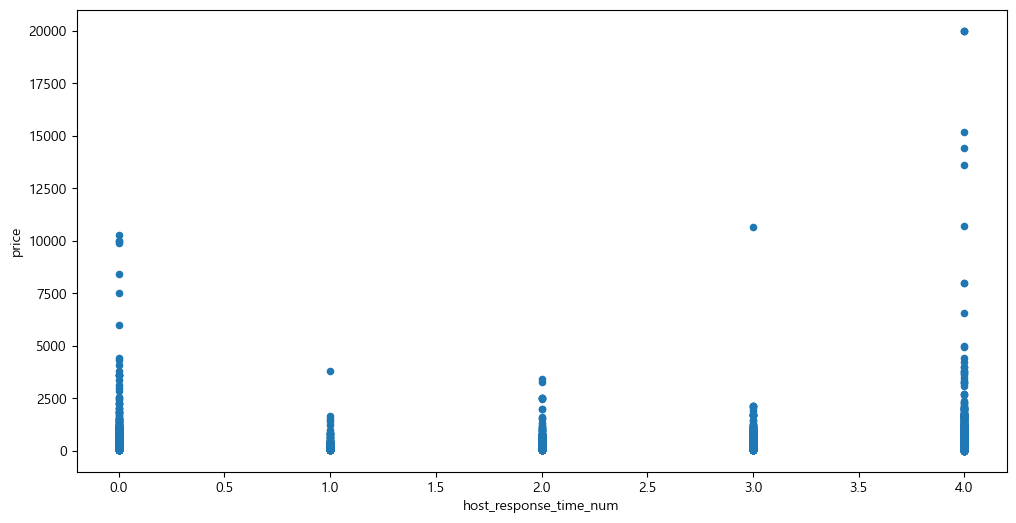

In [12]:
df.plot.scatter(x='host_response_time_num', y='price')

<Axes: title={'center': 'log_price'}, xlabel='host_response_time_num'>

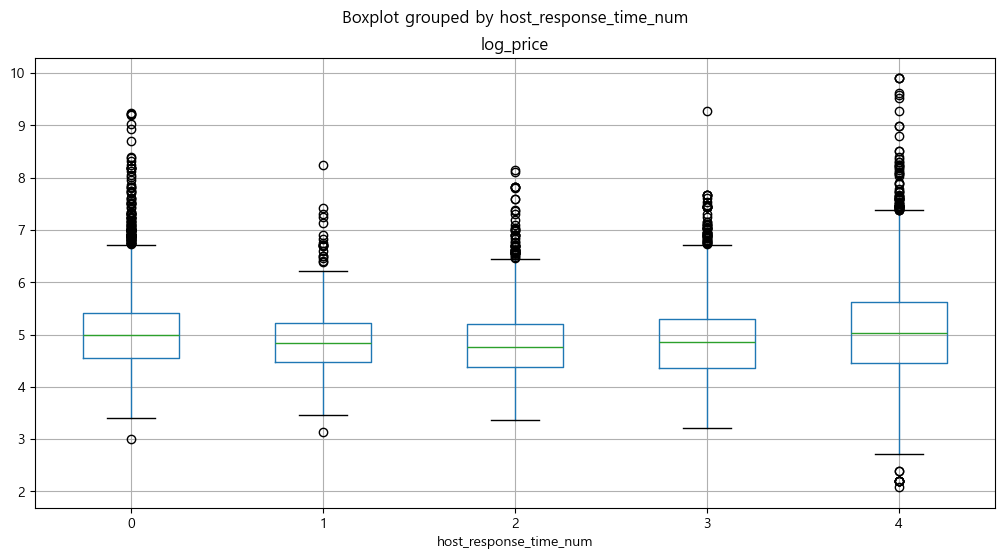

In [13]:
df.assign(log_price=np.log1p(df["price"])).boxplot(column="log_price", by="host_response_time_num")

host_response_rate(호스트 응답률)에 따른 price(가격)상관 여부

In [14]:
#결측치 확인 --4393개
df['host_response_rate'].isna().sum()
df['host_response_rate'].value_counts(dropna=False)

host_response_rate
100%    12885
NaN      4393
99%       727
98%       562
0%        436
90%       349
68%       305
80%       216
97%       196
92%       182
42%       174
50%       173
94%       150
91%       129
96%       126
95%       104
75%        96
67%        90
79%        90
93%        80
48%        78
89%        68
60%        65
83%        63
86%        57
88%        53
70%        50
82%        35
33%        30
87%        28
25%        26
78%        24
85%        24
40%        22
20%        22
81%        21
41%        21
30%        20
57%        18
71%        15
56%        15
10%         8
74%         7
38%         7
53%         6
34%         6
36%         6
65%         6
17%         5
76%         5
63%         4
46%         4
61%         4
77%         3
14%         2
44%         2
58%         2
29%         2
84%         2
72%         2
73%         2
16%         1
43%         1
55%         1
11%         1
62%         1
Name: count, dtype: int64

In [15]:
# host_response_rate "%" 제거 -> float형태로 변경
df['host_response_rate'] = (df['host_response_rate'].str.replace("%", "").pipe(pd.to_numeric, errors="coerce")) / 100
df['host_response_rate']

0         NaN
1         NaN
2        1.00
3        1.00
4        1.00
         ... 
37429     NaN
37430    1.00
37431    0.94
37432    0.89
37433    1.00
Name: host_response_rate, Length: 22308, dtype: float64

In [16]:
# price랑 host_response_rate(호스트 응답률) 상관계수
# 피어슨
pearson_corr = df[['price', 'host_response_rate']].corr()

# 스피어만
spearman_corr = df[["price","host_response_rate"]].corr(method="spearman")

print("피어슨:", pearson_corr)
print("스피어만:", spearman_corr)

피어슨:                        price  host_response_rate
price               1.000000            0.042325
host_response_rate  0.042325            1.000000
스피어만:                        price  host_response_rate
price               1.000000            0.112934
host_response_rate  0.112934            1.000000


<Axes: xlabel='host_response_rate', ylabel='price'>

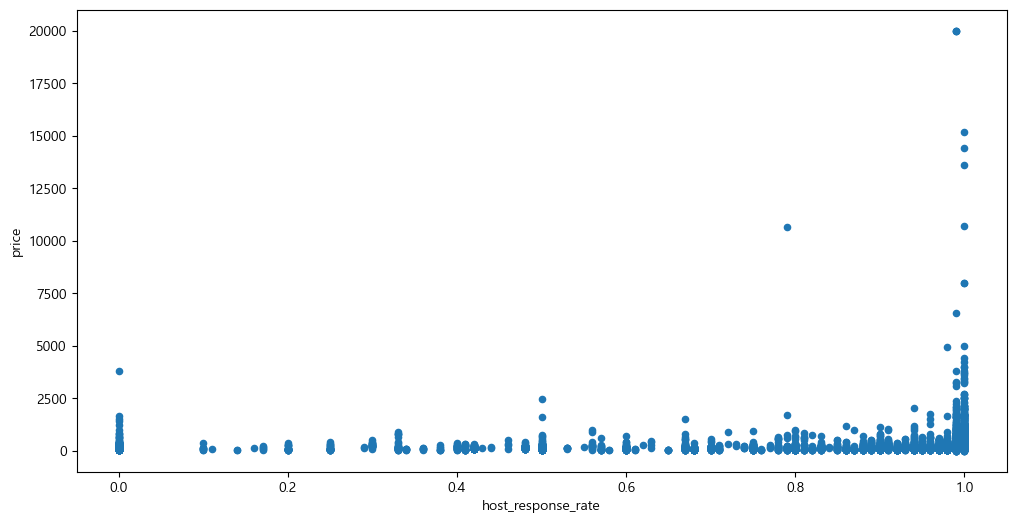

In [17]:
df.plot.scatter(x='host_response_rate', y='price')

host_acceptance_rate(예약요청 수락률)과 price(가격) 상관관계

In [18]:
#결측치 확인 -- 3466개
df['host_acceptance_rate'].isna().sum()
df['host_acceptance_rate'].value_counts(dropna=False)

host_acceptance_rate
100%    4909
NaN     3466
97%     1407
99%     1006
0%       999
83%      478
77%      473
88%      470
50%      451
96%      396
98%      384
67%      377
91%      374
49%      331
82%      290
84%      270
93%      253
60%      252
94%      247
75%      246
86%      243
95%      232
47%      227
80%      219
92%      218
89%      196
90%      179
72%      172
33%      156
71%      143
70%      137
24%      135
87%      129
73%      127
51%      126
79%      113
81%      110
78%      106
55%       99
58%       98
57%       96
85%       89
56%       84
37%       79
25%       78
74%       76
40%       75
48%       70
69%       67
59%       67
52%       64
68%       62
65%       59
46%       58
41%       58
61%       56
76%       53
43%       52
63%       52
39%       50
62%       49
20%       48
64%       48
53%       46
29%       43
30%       39
17%       35
44%       31
8%        30
23%       28
27%       25
54%       25
11%       23
14%       23
42%       21
32% 

In [19]:
df['host_acceptance_rate'] = (df['host_acceptance_rate'].str.replace("%", "").pipe(pd.to_numeric, errors="coerce")) / 100
df['host_acceptance_rate']

0         NaN
1        1.00
2        0.40
3        0.97
4        1.00
         ... 
37429     NaN
37430    0.80
37431    0.99
37432    1.00
37433    0.80
Name: host_acceptance_rate, Length: 22308, dtype: float64

In [20]:
# 피어슨/스피어만 확인
# 피어슨
pearson_corr = df[['price', 'host_acceptance_rate']].corr()

# 스피어만
spearman_corr = df[["price","host_acceptance_rate"]].corr(method="spearman")

print("피어슨:", pearson_corr)
print("스피어만:", spearman_corr)

피어슨:                          price  host_acceptance_rate
price                 1.000000              0.006481
host_acceptance_rate  0.006481              1.000000
스피어만:                         price  host_acceptance_rate
price                 1.00000               0.09998
host_acceptance_rate  0.09998               1.00000


**host_is_superhost(슈퍼호스트 여부)에 따른 price(가격) 상관관계**

In [21]:
#결측치 확인
df['host_is_superhost'].isna().sum()
df['host_is_superhost'].value_counts(dropna=False)

host_is_superhost
f      15799
t       6135
NaN      374
Name: count, dtype: int64

In [22]:
# 결측치 제외/ t : 1, f : 0 으로 변경
tmp = df[df['host_is_superhost'].notna()].copy()
tmp['host_is_superhost_bool'] = tmp['host_is_superhost'].map({"t":1, "f":0})
tmp['host_is_superhost_bool'].value_counts()

host_is_superhost_bool
0    15799
1     6135
Name: count, dtype: int64

In [23]:
# 피어슨/스피어만 확인
# 피어슨
pearson_corr = tmp[['price', 'host_is_superhost_bool']].corr()

# 스피어만
spearman_corr = tmp[["price","host_is_superhost_bool"]].corr(method="spearman")

print("피어슨:", pearson_corr)
print("스피어만:", spearman_corr)

피어슨:                            price  host_is_superhost_bool
price                   1.000000               -0.051083
host_is_superhost_bool -0.051083                1.000000
스피어만:                            price  host_is_superhost_bool
price                   1.000000               -0.067993
host_is_superhost_bool -0.067993                1.000000


<Axes: title={'center': 'log_price'}, xlabel='host_is_superhost_bool'>

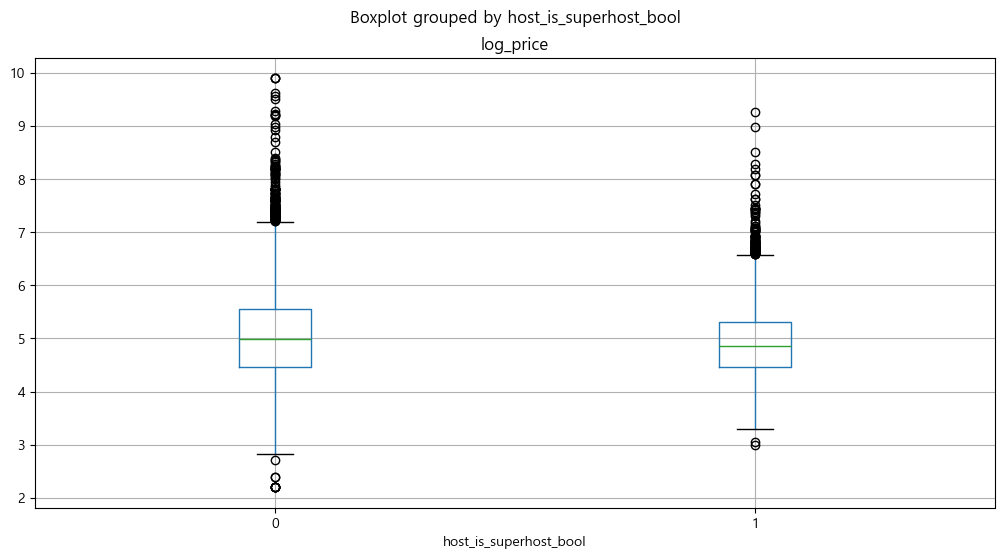

In [24]:
tmp.assign(log_price=np.log1p(tmp["price"])).boxplot(column="log_price", by="host_is_superhost_bool")

In [25]:
tmp.groupby("host_is_superhost_bool")['price'].agg(["count", "mean", "median"])

,count,mean,median
host_is_superhost_bool,,,
0,15799,227.760365,146.0
1,6135,178.781255,129.0


**host_neighbourhood(호스트 동네)에 따른 pirce(가격)영향 여부**

In [26]:
# 결측치 확인 
df['host_neighbourhood'].isna().sum()
df['host_neighbourhood'].value_counts(dropna=False)

host_neighbourhood
NaN                                                                                                           4730
Bedford-Stuyvesant                                                                                            1138
Cambridge                                                                                                     1095
Jamaica                                                                                                        834
Williamsburg                                                                                                   756
                                                                                                              ... 
Charleston                                                                                                       1
Center City East                                                                                                 1
Colgate Center                                               

- 호스트의 동네는 이 분석에서 의미가 없다고 판단됨

**host_listings_count(호스트의 전체 등록 숙소 수)와 price(가격)의 상관**

In [27]:
# 결측치 확인 
df['host_listings_count'].isna().sum()
df['host_listings_count'].value_counts(dropna=False)

host_listings_count
1.0       6791
2.0       2983
3.0       1588
4.0       1096
5255.0    1094
          ... 
187.0        1
270.0        1
328.0        1
114.0        1
60.0         1
Name: count, Length: 110, dtype: int64

호스트 아이디당 동일한 값을 가지기 때문에(중복행) 제외

**host_total_listings_count(호스트 전체 숙소 수)와 price(가격)의 상관**

In [28]:
df['host_total_listings_count']

0           3.0
1           1.0
2           3.0
3           1.0
4           2.0
          ...  
37429       2.0
37430      33.0
37431    1974.0
37432      38.0
37433      33.0
Name: host_total_listings_count, Length: 22308, dtype: float64

In [29]:
# 결측치 확인 
display(df['host_total_listings_count'].isna().sum())
display(df['host_total_listings_count'].value_counts(dropna=False).head(10))

np.int64(20)

host_total_listings_count
1.0       3989
2.0       2847
3.0       2029
4.0       1411
5458.0    1094
5.0       1048
6.0        794
7.0        607
8.0        490
9.0        397
Name: count, dtype: int64

<Axes: xlabel='host_total_listings_count', ylabel='price'>

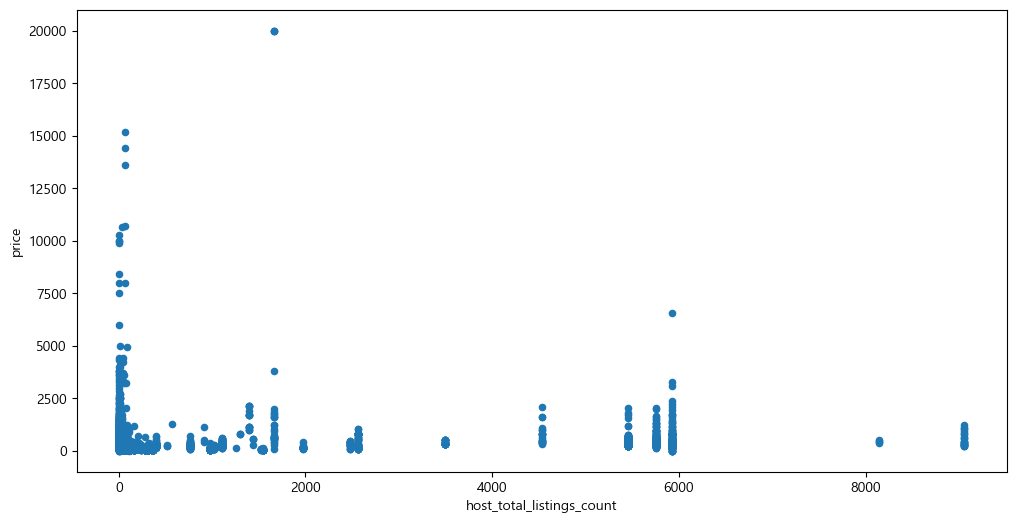

In [30]:
tmp = df[['price', 'host_total_listings_count']].dropna()
tmp.plot.scatter(x="host_total_listings_count", y='price')

In [31]:
# 피어슨/스피어만 확인
# 피어슨
pearson_corr = tmp[['price', 'host_total_listings_count']].corr()

# 스피어만
spearman_corr = tmp[["price","host_total_listings_count"]].corr(method="spearman")
print("피어슨:", pearson_corr)
print("스피어만:", spearman_corr)

피어슨:                               price  host_total_listings_count
price                      1.000000                   0.160511
host_total_listings_count  0.160511                   1.000000
스피어만:                              price  host_total_listings_count
price                      1.00000                    0.08538
host_total_listings_count  0.08538                    1.00000


**host_verifications(호스트 인증정보)에 따른 price(가격) 영향**

In [32]:
display(df['host_verifications'].isna().sum())
display(df['host_verifications'].value_counts(dropna=False))

np.int64(20)

host_verifications
['email', 'phone']                  16852
['email', 'phone', 'work_email']     3230
['phone']                            2138
['phone', 'work_email']                60
NaN                                    20
['email']                               6
[]                                      2
Name: count, dtype: int64

**host_has_profile_pic(프로필 사진여부)에 따른 price(가격) 영향 여부**

In [33]:
# 결측치 확인하기
display(df['host_has_profile_pic'].isna().sum())
display(df['host_has_profile_pic'].value_counts(dropna=False).head(10))

np.int64(20)

host_has_profile_pic
t      21646
f        642
NaN       20
Name: count, dtype: int64

In [34]:
# 결측치 제외하고 , t/f 0이랑 1로 바꾸기
tmp = df[df['host_has_profile_pic'].notna()].copy()
tmp['host_has_profile_pic_bool'] = tmp['host_has_profile_pic'].map({"t":1, "f":0})
tmp['host_has_profile_pic_bool'].value_counts()

host_has_profile_pic_bool
1    21646
0      642
Name: count, dtype: int64

In [35]:
# 피어슨/스피어만 확인
# 피어슨
pearson_corr = tmp[['price', 'host_has_profile_pic_bool']].corr()

# 스피어만
spearman_corr = tmp[["price","host_has_profile_pic_bool"]].corr(method="spearman")

print("피어슨:", pearson_corr)
print("스피어만:", spearman_corr)

피어슨:                               price  host_has_profile_pic_bool
price                      1.000000                  -0.004845
host_has_profile_pic_bool -0.004845                   1.000000
스피어만:                               price  host_has_profile_pic_bool
price                      1.000000                  -0.001818
host_has_profile_pic_bool -0.001818                   1.000000


**host_identity_verified(신원인증여부)에 따른 price(가격) 영향 여부**

In [36]:
# 결측치 확인하기
display(df['host_identity_verified'].isna().sum())
display(df['host_identity_verified'].value_counts(dropna=False).head(10))

np.int64(20)

host_identity_verified
t      20423
f       1865
NaN       20
Name: count, dtype: int64

In [37]:
# 결측치 제외하고 , t/f 0이랑 1로 바꾸기
tmp = df[df['host_identity_verified'].notna()].copy()
tmp['host_identity_verified_bool'] = tmp['host_identity_verified'].map({"t":1, "f":0})
tmp['host_identity_verified_bool'].value_counts()

host_identity_verified_bool
1    20423
0     1865
Name: count, dtype: int64

In [38]:
# 피어슨/스피어만 확인
# 피어슨
pearson_corr = tmp[['price', 'host_identity_verified_bool']].corr()

# 스피어만
spearman_corr = tmp[["price","host_identity_verified_bool"]].corr(method="spearman")

print("피어슨:", pearson_corr)
print("스피어만:", spearman_corr)

피어슨:                                 price  host_identity_verified_bool
price                        1.000000                     0.025129
host_identity_verified_bool  0.025129                     1.000000
스피어만:                                price  host_identity_verified_bool
price                        1.00000                      0.06335
host_identity_verified_bool  0.06335                      1.00000


<Axes: title={'center': 'log_price'}, xlabel='host_identity_verified_bool'>

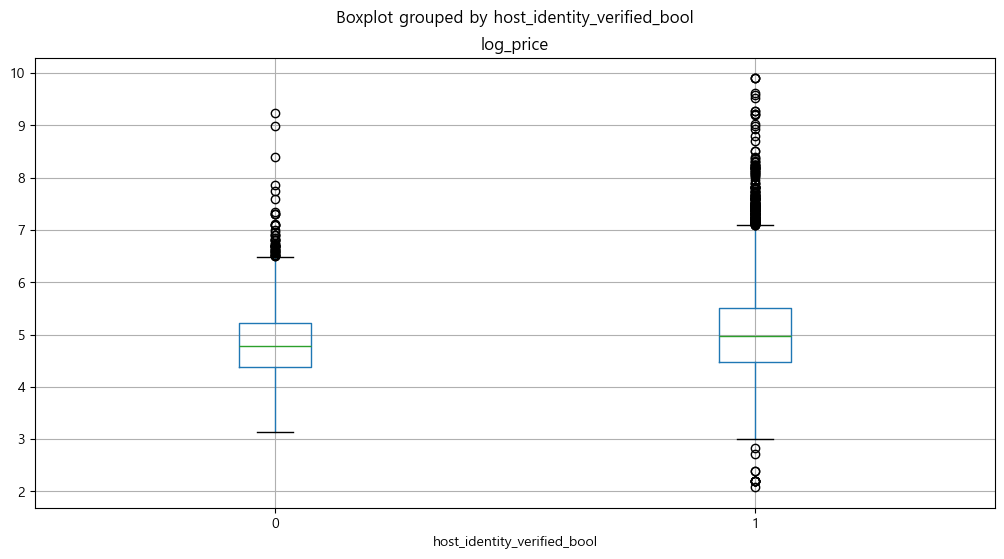

In [39]:
# 가격 log씌워서 boxplot
tmp.assign(log_price=np.log1p(tmp["price"])).boxplot(column="log_price", by="host_identity_verified_bool")

**neighbourhood(숙소가 속한 동네)에 따른 price(가격)영향 여부**

In [40]:
# 결측치 확인하기
display(df['neighbourhood'].isna().sum())
display(df['neighbourhood'].value_counts(dropna=False, normalize=True).head(10))

np.int64(10046)

neighbourhood
Neighborhood highlights    0.549668
NaN                        0.450332
Name: proportion, dtype: float64

- 결측치가 45% 가량으로 제외 필요..

**neighbourhood_cleansed(정제된 동네이름)에 따른 price(가격)영향 여부**

In [41]:
# 결측치 확인하기
display(df['neighbourhood_cleansed'].isna().sum())
display(df['neighbourhood_cleansed'].value_counts(dropna=False).head(10))

np.int64(0)

neighbourhood_cleansed
Bedford-Stuyvesant    1545
Midtown               1461
Upper East Side       1042
Hell's Kitchen        1036
Harlem                1031
Upper West Side        929
Williamsburg           853
Bushwick               758
Crown Heights          648
Chelsea                520
Name: count, dtype: int64

In [42]:
# 상위 15개만, 가격에 log씌우기
tmp = df.copy()
tmp["log_price"] = np.log1p(tmp['price'])

top15_list = tmp['neighbourhood_cleansed'].value_counts().head(15).index
top15 = tmp[tmp['neighbourhood_cleansed'].isin(top15_list)]

<Axes: title={'center': 'log_price'}, xlabel='neighbourhood_cleansed'>

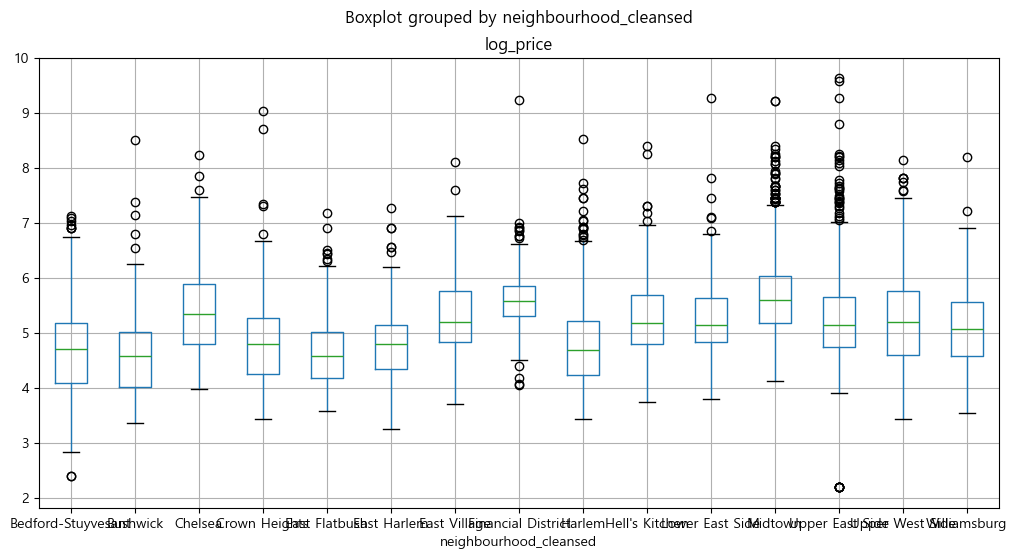

In [43]:
# boxplot
top15.boxplot(column="log_price", by="neighbourhood_cleansed")

In [44]:
# latitude(위도)랑 price랑 비교
df[['price', 'latitude']].corr()

,price,latitude
price,1.000000,0.030858
latitude,0.030858,1.000000


<Axes: xlabel='latitude', ylabel='price'>

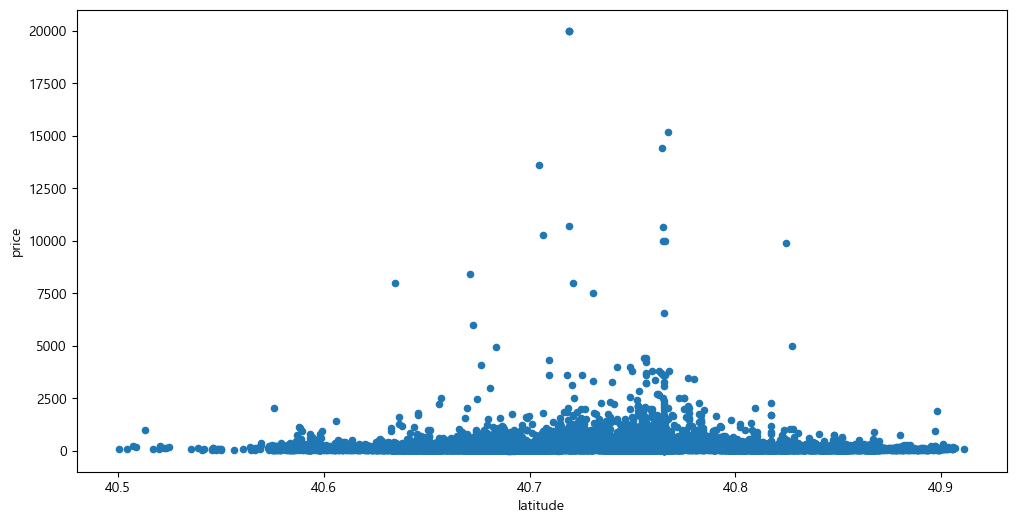

In [45]:
df.plot.scatter(x='latitude', y='price')

상관계수 0.03 price와 latitude(위도)는 거의 관계가 없다.

In [46]:
# price와 host_total_listings_count(호스트 전체 숙소 수)의 상관관계
df[['price', 'host_total_listings_count']].corr()

,price,host_total_listings_count
price,1.000000,0.160511
host_total_listings_count,0.160511,1.000000


In [47]:
# 스피어만
df[["price","host_total_listings_count"]].corr(method="spearman")

,price,host_total_listings_count
price,1.00000,0.08538
host_total_listings_count,0.08538,1.00000


<Axes: xlabel='host_total_listings_count', ylabel='price'>

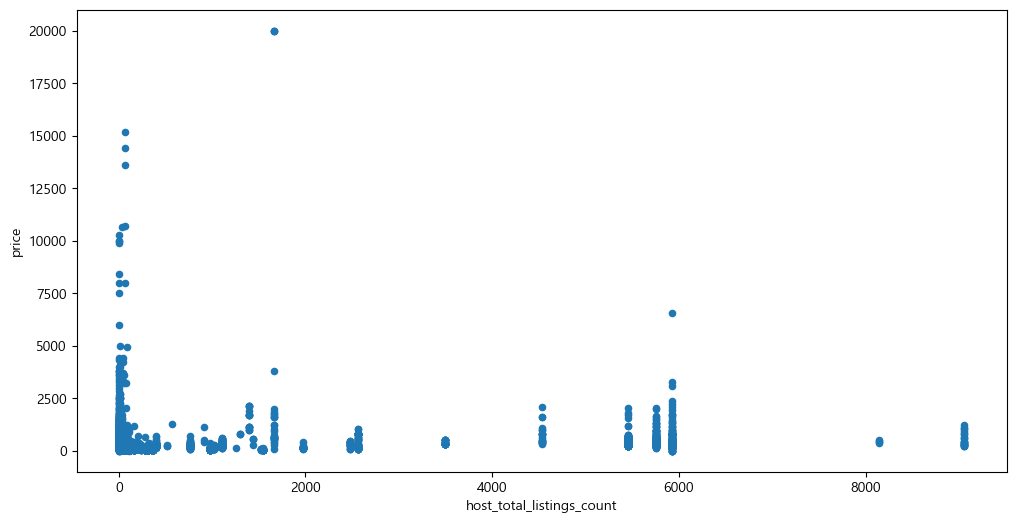

In [48]:
df.plot.scatter(x='host_total_listings_count', y='price')

In [49]:
# price랑 host_listings_count(호스트의 전체 등록 숙소 수) 상관계수
df[['price', 'host_listings_count']].corr()

,price,host_listings_count
price,1.000000,0.146147
host_listings_count,0.146147,1.000000


In [50]:
# 스피어만
df[["price","host_listings_count"]].corr(method="spearman")

,price,host_listings_count
price,1.00000,0.07623
host_listings_count,0.07623,1.00000


<Axes: xlabel='host_listings_count', ylabel='price'>

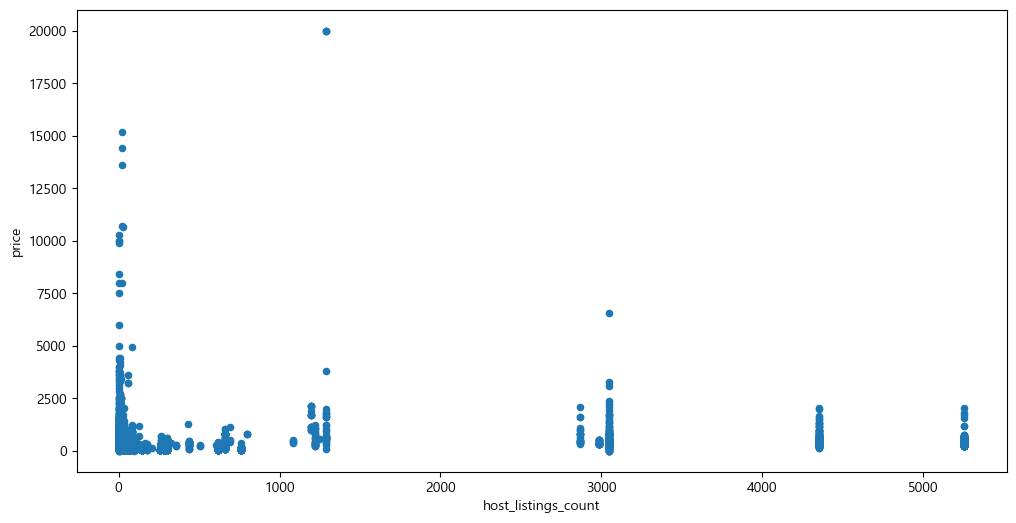

In [51]:
df.plot.scatter(x='host_listings_count', y='price')

In [52]:
# price랑 host_identity_verified(신원인증여부) 상관계수

#데이터 확인 -> t/f 로 분류
df['host_identity_verified'].isna().sum()
df['host_identity_verified'].value_counts(dropna=False)

host_identity_verified
t      20423
f       1865
NaN       20
Name: count, dtype: int64

In [53]:
# 결측지 제외 t:1, f:0으로 변경
tmp = df[df['host_identity_verified'].notna()].copy()
tmp['host_identity_verified_bool'] = tmp['host_identity_verified'].map({"t":1, "f":0})
tmp['host_identity_verified_bool'] 

0        1
1        1
2        1
3        1
4        1
        ..
37429    1
37430    1
37431    1
37432    1
37433    1
Name: host_identity_verified_bool, Length: 22288, dtype: int64

In [54]:
tmp['host_identity_verified_bool'].value_counts()

host_identity_verified_bool
1    20423
0     1865
Name: count, dtype: int64

In [55]:
# price랑 host_identity_verified(신원인증여부) 상관계수
tmp[['price', 'host_identity_verified_bool']].corr()

,price,host_identity_verified_bool
price,1.000000,0.025129
host_identity_verified_bool,0.025129,1.000000


In [56]:
# 스피어만
tmp[["price","host_identity_verified_bool"]].corr(method="spearman")

,price,host_identity_verified_bool
price,1.00000,0.06335
host_identity_verified_bool,0.06335,1.00000


<Axes: xlabel='host_identity_verified_bool', ylabel='price'>

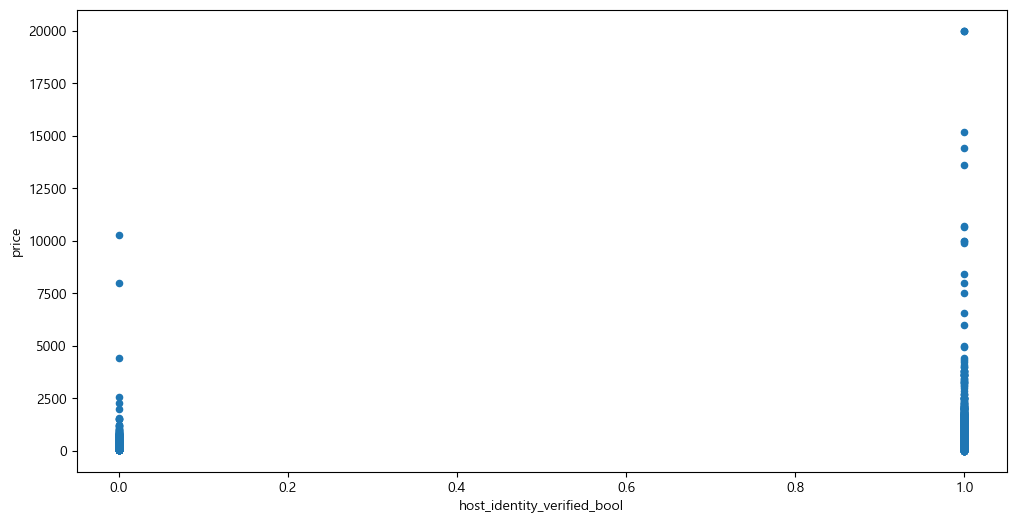

In [57]:
tmp.plot.scatter(x='host_identity_verified_bool', y='price')

<Axes: title={'center': 'log_price'}, xlabel='host_identity_verified_bool'>

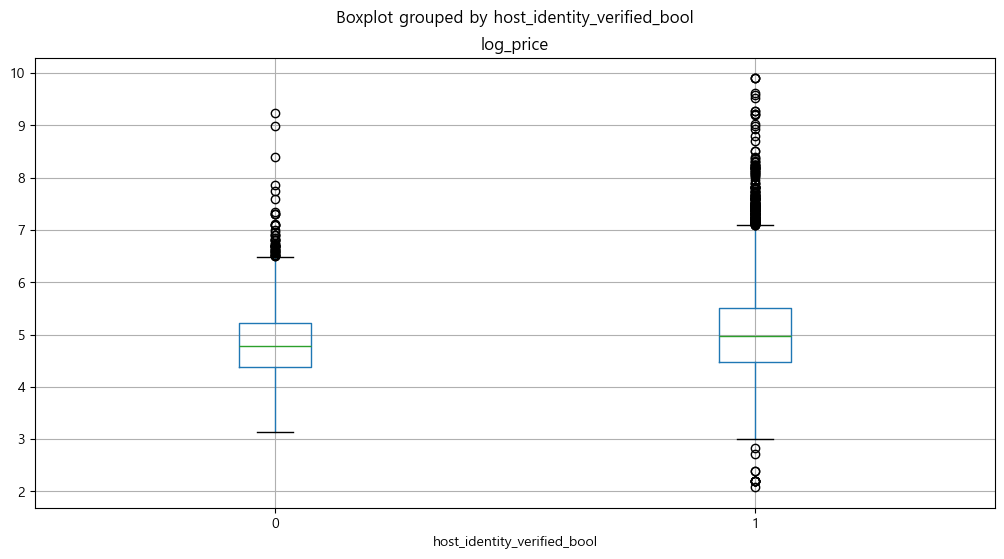

In [58]:
tmp.assign(log_price=np.log1p(tmp["price"])).boxplot(column="log_price", by="host_identity_verified_bool")

In [59]:
# 인증 vs 미인증 가격의 중앙값/평균 차이
tmp.groupby("host_identity_verified_bool")["price"].agg(["count","mean","median"])

,count,mean,median
host_identity_verified_bool,,,
0,1865,178.304021,119.0
1,20423,217.122509,143.0


In [60]:
df.sort_values("price", ascending=False)[["host_id","neighbourhood_cleansed","host_is_superhost", "room_type", "price"]].head(10)  # 상위 10개

,host_id,neighbourhood_cleansed,host_is_superhost,room_type,price
27926,326084746,SoHo,f,Private room,20000.0
27927,326084746,SoHo,f,Private room,20000.0
27925,326084746,SoHo,f,Private room,20000.0
28168,34906299,Upper East Side,f,Entire home/apt,15200.0
28167,34906299,Upper East Side,f,Entire home/apt,14399.0
23309,34906299,Battery Park City,f,Entire home/apt,13600.0
27845,34906299,Lower East Side,f,Entire home/apt,10688.0
29905,252866861,Upper East Side,t,Entire home/apt,10664.0
19990,57586379,Financial District,f,Entire home/apt,10271.0
26219,76166434,Midtown,f,Entire home/apt,10000.0


In [61]:
df['number_of_reviews']

0          9
1        102
2         43
3        241
4        274
        ... 
37429      0
37430      0
37431      0
37432      0
37433      0
Name: number_of_reviews, Length: 22308, dtype: int64

# 전처리 3part(15 ~21)

In [62]:
#필요한 컬럼 37개만 가져오기
df = pd.read_csv("data/2025_Airbnb_NYC_listings.csv")

choice = [
    "id","name","description","host_id","host_since","host_response_time",
    "host_response_rate","host_acceptance_rate","host_is_superhost",
    "neighbourhood_cleansed","neighbourhood_group_cleansed",
    "latitude","longitude","property_type","room_type","accommodates",
    "bedrooms","beds","amenities","price","availability_365",
    "number_of_reviews","number_of_reviews_ltm",
    "estimated_occupancy_l365d","estimated_revenue_l365d",
    "review_scores_rating","review_scores_accuracy","review_scores_cleanliness",
    "review_scores_checkin","review_scores_communication","review_scores_location",
    "review_scores_value",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
    "reviews_per_month"
]

df_ch = df[choice]
df_ch

,id,name,description,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,amenities,price,availability_365,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,36121,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,62165,2009-12-11,NaN,NaN,NaN,f,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",$200.00,362,9,0,0,0.0,4.88,5.00,4.80,5.00,5.00,5.00,5.00,1,0,1,0,0.05
1,36647,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,157798,2010-07-04,NaN,NaN,100%,f,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",$82.00,204,102,0,0,0.0,4.77,4.82,4.76,4.88,4.90,4.38,4.71,1,0,1,0,0.58
2,38663,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...",165789,2010-07-13,within a few hours,100%,40%,f,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",$765.00,326,43,0,0,0.0,4.70,4.83,4.52,4.88,4.88,4.86,4.62,1,0,1,0,0.28
3,38833,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,166532,2010-07-14,within an hour,100%,97%,t,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",$139.00,25,241,42,255,35445.0,4.85,4.87,4.50,4.96,4.96,4.79,4.82,1,1,0,0,1.36
4,39282,“Work-from-home” from OUR home.,*Monthly Discount will automatically apply <br...,168525,2010-07-16,within an hour,100%,100%,t,Williamsburg,Brooklyn,40.710651,-73.950874,Private room in rental unit,Private room,2,1.0,1.0,"[""Oven"", ""Rice maker"", ""Laundromat nearby"", ""L...",$130.00,38,274,12,154,20020.0,4.82,4.83,4.61,4.94,4.88,4.85,4.78,2,0,2,0,1.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22303,1366333532374850165,Beautiful 1-Bed Apt in Harlem!,Welcome to your temporary home in the vibrant ...,40019013,2015-07-30,NaN,NaN,NaN,f,Harlem,Manhattan,40.813794,-73.952399,Private room in rental unit,Private room,1,1.0,1.0,"[""Air conditioning"", ""Carbon monoxide alarm"", ...",$72.00,358,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,1,0,NaN
22304,1366717321390111215,Private Room w/ Ensuite Bath H,Stylish Private Rooms w/ En-Suite Baths in Bro...,483056418,2022-10-10,within an hour,100%,80%,t,Bedford-Stuyvesant,Brooklyn,40.685500,-73.919510,Private room in rental unit,Private room,2,1.0,0.0,"[""Air conditioning"", ""Carbon monoxide alarm"", ...",$58.00,363,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24,0,24,0,NaN
22305,1366721904709517353,2 Bedroom on East Side,Located in the Murray Hill area and occupies a...,30283594,2015-03-30,within an hour,94%,99%,f,Kips Bay,Manhattan,40.745290,-73.979380,Entire rental unit,Entire home/apt,5,2.0,3.0,"[""Air conditioning"", ""Carbon monoxide alarm"", ...",$299.00,99,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48,48,0,0,NaN
22306,1366722692755341871,Stylish 2Bd near Bryant Park,Enjoy everything the city has to offer while l...,407304997,2021-06-15,within an hour,89%,100%,f,Theater District,Manhattan,40.757133,-73.983124,Entire rental unit,Entire home/apt,4,2.0,2.0,"[""Oven"", ""Gym"", ""Blender"", ""Dedicated works

## 맡은 컬럼 확인(15 ~ 21)

In [63]:
# ============================================================
# 15 ~ 21 주요 컬럼 설명
# ============================================================
# • bedrooms                    : 침실 수
# • beds                        : 침대 수
# • amenities                   : 편의시설
# • price                       : 가격
# • availability_365            : 365일 예약 가능일
# • number_of_reviews           : 리뷰 수
# • number_of_reviews_ltm       : 최근 12개월 리뷰 수

In [64]:
df_ch[['bedrooms','beds','amenities','price','availability_365','number_of_reviews','number_of_reviews_ltm']].info()

<class 'pandas.DataFrame'>
RangeIndex: 22308 entries, 0 to 22307
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   bedrooms               22259 non-null  float64
 1   beds                   22229 non-null  float64
 2   amenities              22308 non-null  str    
 3   price                  22308 non-null  str    
 4   availability_365       22308 non-null  int64  
 5   number_of_reviews      22308 non-null  int64  
 6   number_of_reviews_ltm  22308 non-null  int64  
dtypes: float64(2), int64(3), str(2)
memory usage: 1.2 MB


### 
- bedrooms 
- beds   
- amenities 
- price
- availability_365 
- number_of_reviews 
- number_of_reviews_ltm 

데이터 확인

### bedrooms

In [65]:
# 결측치 확인과 각각 몇개씩 있는지 확인
display(df_ch['bedrooms'].isna().sum())
display(df_ch['bedrooms'].value_counts(dropna=False))

np.int64(49)

bedrooms
1.0     14132
2.0      3863
0.0      2138
3.0      1444
4.0       449
5.0       156
6.0        53
NaN        49
7.0        13
9.0         5
8.0         4
14.0        1
15.0        1
Name: count, dtype: int64

- 결측치 49개 확인
→ 침실 방이 없을수도 있지. 아니면 침실이라고 표기를 안하던가? 근데 이미 0인 값이 있다. -> 49개면 2만행에 비해 적기 때문에 drop

In [66]:
df_ch.loc[df_ch["bedrooms"].isna(), ["host_id", "name", "price", "room_type", "beds", "bedrooms"]]

,host_id,name,price,room_type,beds,bedrooms
23,30193,Midtown Pied-a-terre,$175.00,Entire home/apt,1.0,NaN
68,120223,East Village Sanctuary,$100.00,Entire home/apt,2.0,NaN
304,1981742,Stylish Designer Studio with Piano,$130.00,Entire home/apt,1.0,NaN
5335,33452526,Cozy apartment on the Upper East aside,$250.00,Entire home/apt,1.0,NaN
5557,22345670,My Beach house,$125.00,Private room,1.0,NaN
5775,86368678,Amazing modern place near JFK,$60.00,Private room,1.0,NaN
5947,51548122,138 Bowery-Modern Queen Studio,$150.00,Entire home/apt,1.0,NaN
5948,51548122,Cozy Studio Apartment,$110.00,Private room,1.0,NaN
6679,55948559,XL Comfort Room.,$43.00,Private room,1.0,NaN
7600,384532776,Beautiful & modern studio doorman elevator w/d...,$110.00,Entire home/apt,2.0,NaN


In [67]:
#룸 타입별로 결측치 개수
df_ch.loc[df_ch["bedrooms"].isna(), "room_type"].value_counts(dropna=False)

room_type
Entire home/apt    28
Shared room        16
Private room        5
Name: count, dtype: int64

In [68]:
df_ch = df_ch.dropna(subset=["bedrooms"])

In [69]:
display(df_ch['bedrooms'].isna().sum())
display(df_ch['bedrooms'].value_counts(dropna=False))

np.int64(0)

bedrooms
1.0     14132
2.0      3863
0.0      2138
3.0      1444
4.0       449
5.0       156
6.0        53
7.0        13
9.0         5
8.0         4
14.0        1
15.0        1
Name: count, dtype: int64

beds 전처리

In [70]:
display(df_ch['beds'].isna().sum())
display(df_ch['beds'].value_counts(dropna=False))

np.int64(78)

beds
1.0     12962
2.0      5114
3.0      1896
4.0       911
0.0       634
5.0       328
6.0       180
NaN        78
7.0        66
8.0        54
9.0        17
10.0        7
12.0        4
13.0        3
11.0        2
42.0        1
14.0        1
21.0        1
Name: count, dtype: int64

- 결측값 78개 확인 -> bedrooms는 있는데 beds가 없는 경우가 있는데?
-> 

In [71]:
df_ch.loc[df_ch["beds"].isna(), ["host_id", "name", "price", "room_type", "bedrooms", "beds"]]

,host_id,name,price,room_type,bedrooms,beds
5617,350773,NYU private quiet room in 1BR Apartment,$161.00,Private room,1.0,NaN
5620,61391963,Polished Executive Apt Lexington Ave,$142.00,Entire home/apt,0.0,NaN
5692,27107891,Live like a Brooklynite in heart of Williamsburg,$143.00,Private room,1.0,NaN
5696,26924376,Luxury (Sky blue) 3 BED Apartment,$150.00,Entire home/apt,3.0,NaN
5769,314493836,PRIVATE SAFE ROOMN QUIET FAMILY RESIDENTAL AREA,$475.00,Private room,1.0,NaN
5782,204704622,Good Room New apartment in Williamsburg,$48.00,Private room,1.0,NaN
5815,4373926,1 Bedroom in Harlem for the summer,$50.00,Entire home/apt,1.0,NaN
5860,342548185,Near to the city,$100.00,Private room,1.0,NaN
5998,236572440,Exquisite Single Bedroom in Shared Apartment,$83.00,Private room,1.0,NaN
6195,30532557,Private Bedroom/ Retro large Apt 15 mins to City!,$43.00,Private room,1.0,NaN


In [72]:
# bedrooms가 1이상인데 beds가 0인 행 확인 -- 571개
df_ch.loc[(df_ch["bedrooms"]>=1) & (df_ch["beds"] == 0),["host_id", "name", "price", "room_type", "bedrooms", "beds"]]

,host_id,name,price,room_type,bedrooms,beds
189,116599,The Brooklyn Waverly,$800.00,Entire home/apt,1.0,0.0
260,2027013,"2RW - NEW RENO - EV STUDIO, WASHER/DRYER OFF ...",$130.00,Entire home/apt,1.0,0.0
296,2647578,Large Bedroom with Modern Private Bathroom,$120.00,Private room,1.0,0.0
306,61531,Red Hook Modern,$126.00,Entire home/apt,1.0,0.0
382,1410714,Brooklyn Livin',$92.00,Entire home/apt,1.0,0.0
...,...,...,...,...,...,...
22265,483056418,Furnished Private Room & Bath H,$58.00,Private room,1.0,0.0
22284,107434423,"Blueground | Clinton Hill, pool, gym & AC, nr ...",$298.00,Entire home/apt,1.0,0.0
22285,107434423,"Blueground | Clinton Hill, pool, gym & AC, nr ...",$298.00,Entire home/apt,1.0,0.0
22304,483056418,Private Room w/ Ensuite Bath H,$58.00,Private room,1.0,0.0


In [73]:
# bedrooms가 1이상인데 beds가 결측인 행 확인 -- 68개
((df_ch["bedrooms"]>=1) & (df_ch["beds"].isna())).sum()

np.int64(68)

In [74]:
#룸 타입별로 beds가 결측인 행 개수
df_ch.loc[df_ch["beds"].isna(), "room_type"].value_counts(dropna=False)

room_type
Private room       57
Entire home/apt    21
Name: count, dtype: int64

룸 타입별로 봤을 때, pirvate room 비중이 조금 더 큼
-> 그럼 중앙값으로 채워본다? -> 찍어보니 1 or 2임 -> 중앙값으로 결측치 채움

In [75]:
# 룸 타입별 beds 중앙값
df_ch.groupby("room_type")["beds"].median()

room_type
Entire home/apt    2.0
Hotel room         2.0
Private room       1.0
Shared room        1.0
Name: beds, dtype: float64

In [76]:
# 룸 타입별로 중앙값으로 beds 결측값 채우기
df_ch["beds"] = df_ch["beds"].fillna(df_ch.groupby("room_type")["beds"].transform("median"))
df_ch["beds"].value_counts()

beds
1.0     13019
2.0      5135
3.0      1896
4.0       911
0.0       634
5.0       328
6.0       180
7.0        66
8.0        54
9.0        17
10.0        7
12.0        4
13.0        3
11.0        2
42.0        1
14.0        1
21.0        1
Name: count, dtype: int64

In [77]:
df_ch["beds"].isna().sum()

np.int64(0)

### price

In [78]:
# price "$", "," 제거 -> float형태로 변경
df_ch['price'] = (df_ch['price'].str.replace("$", "").str.replace(",","").astype(float))
df_ch['price']

0        200.0
1         82.0
2        765.0
3        139.0
4        130.0
         ...  
22303     72.0
22304     58.0
22305    299.0
22306    200.0
22307     58.0
Name: price, Length: 22259, dtype: float64

In [79]:
#결측값 확인 -- 없음
display(df_ch['price'].isna().sum())
display(df_ch['price'].value_counts(dropna=False))

np.int64(0)

price
150.0     375
100.0     367
120.0     289
90.0      278
200.0     276
         ... 
1401.0      1
852.0       1
1239.0      1
872.0       1
16.0        1
Name: count, Length: 1021, dtype: int64

In [80]:
df_ch['price'].describe()

count    22259.000000
mean       214.037198
std        428.025529
min          7.000000
25%         85.000000
50%        140.000000
75%        240.000000
max      20000.000000
Name: price, dtype: float64

In [81]:
pd.set_option('display.max_colwidth', None)   # description 안 잘리게

df_ch.loc[(df_ch['price']>=20000),["host_id", "name", "price", "room_type", "description"]]

,host_id,name,price,room_type,description
14131,326084746,1-Bedroom Hotel Suite - 1 bed,20000.0,Private room,"The 640 square foot Howard Suite at 11 Howard boasts a premium New York City retreat. Light oak floors and custom-designed furniture decorate the suite while the marble-clad bathrooms feature organic bath products. Enjoy views of Howard Street from expansive windows. Offering a variety of complimentary extras, guests enjoy free candles, minibar items, and access to The Blond—a stylish NYC lounge. The create-your-own-minibar feature allows you to personalize your stay and the in-suite tablet make"
14132,326084746,2 Connecting Hotel Suites - 2 beds,20000.0,Private room,"The 640 square foot Howard Suite at 11 Howard boasts a premium New York City retreat. Light oak floors and custom-designed furniture decorate the suite while the marble-clad bathrooms feature organic bath products. Enjoy views of Howard Street from expansive windows. Offering a variety of complimentary extras, guests enjoy free candles, minibar items, and access to The Blond—a stylish NYC lounge. The create-your-own-minibar feature allows you to personalize your stay and the in-suite tablet make"
14133,326084746,1-Bedroom Hotel Suite - 2 beds,20000.0,Private room,"Revel in a private, rooftop terrace with views of Lafayette or Howard Street in the Terrace Suite at 11 Howard. This 1,890 square foot retreat features a separate bedroom, a dining area for up to eight people, a living room, and a fully-equipped kitchenette. Light oak floors are complimented by custom furniture and bamboo area rugs—providing the suite with a modernly elegant feel. Enjoy complimentary gifts, such as scented candles and minibar refreshments. For a night out, guests receive free ac"


3개밖에 안돼서 IQR방식으로 처리함.

In [82]:
# IQR 이상치 제거
q_1 = np.percentile(df_ch['price'], q=25)
q_3 = np.percentile(df_ch['price'], q=75)
iqr = q_3 - q_1

lower_whisker = q_1 - 1.5*iqr
upper_whisker = q_3 + 1.5*iqr

price_processed = df_ch.loc[df_ch['price'].between(lower_whisker,upper_whisker)].copy()
price_processed['price'].describe()

count    20782.000000
mean       158.877538
std        100.578273
min          7.000000
25%         81.000000
50%        130.000000
75%        210.000000
max        472.000000
Name: price, dtype: float64

In [83]:
print("Q1:", q_1)
print("Q3:", q_3)
print("IQR:", iqr)
print("lower:", lower_whisker)
print("upper:", upper_whisker)

Q1: 85.0
Q3: 240.0
IQR: 155.0
lower: -147.5
upper: 472.5


In [84]:
# 이상치 몇개나 날라갔지? -- 1477개
before = len(df_ch)
after = len(price_processed)
print("before:", {before}, "after: ", {after}, {before - after})

before: {22259} after:  {20782} {1477}


In [85]:
df_ch_raw = df_ch.copy()  # 원본보존
df_ch = df_ch.loc[df_ch['price'].between(lower_whisker,upper_whisker)].copy()  # 이상치 제거한거 덮어쓰기

In [86]:
df_ch

,id,name,description,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,amenities,price,availability_365,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,36121,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neighborhood. I split my time between Brooklyn and the Hudson Valley. Am looking for someone to share the space who is also willing to water plants and get mail periodically.,62165,2009-12-11,NaN,NaN,NaN,f,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wifi"", ""Kitchen"", ""Elevator"", ""City skyline view"", ""Heating""]",200.0,362,9,0,0,0.0,4.88,5.00,4.80,5.00,5.00,5.00,5.00,1,0,1,0,0.05
1,36647,"1 Bedroom & your own Bathroom, Elevator Apartment","Private bedroom with your own bathroom in a 2 bedroom, 2 bathroom, modern-style furnished elevator condo, 2007 built.",157798,2010-07-04,NaN,NaN,100%,f,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"", ""Dedicated workspace"", ""Dining table"", ""Microwave"", ""Hair dryer"", ""Host greets you"", ""Essentials"", ""Long term stays allowed"", ""Iron"", ""Bed linens"", ""Elevator"", ""Bathtub"", ""Heating"", ""Free street parking"", ""Paid washer \u2013 In building"", ""Air conditioning"", ""Toaster"", ""Cleaning products"", ""Clothing storage"", ""Dishes and silverware"", ""Hot water"", ""Wifi"", ""Kitchen"", ""Coffee maker"", ""Refrigerator"", ""Dryer \u2013 In building"", ""Hangers"", ""Shampoo"", ""Freezer"", ""Room-darkening shades""]",82.0,204,102,0,0,0.0,4.77,4.82,4.76,4.88,4.90,4.38,4.71,1,0,1,0,0.58
3,38833,Spectacular West Harlem Garden Apt,"This is a very large and unique space. An incredibly quiet apartment on one of the nicest blocks in Manhattan. Its a very spacious (800 sq ft) home with an 800 sq ft garden /patio with right outside your bedroom door ! Despite the country-quiet, you are only 100 feet away from the subway which gets you in to the center of Manhattan in 8-10 minutes..",166532,2010-07-14,within an hour,100%,97%,t,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: closet"", ""Single level home"", ""36 inch HDTV with Chromecast, Roku, Amazon Prime Video, Hulu, Fire TV"", ""Luggage dropoff allowed"", ""Dedicated workspace"", ""Extra pillows and blankets"", ""Dining table"", ""Cooking basics"", ""Coffee"", ""Fire pit"", ""Microwave"", ""Stainless steel gas stove"", ""Hair dryer"", ""Window AC unit"", ""Wine glasses"", ""Essentials"", ""Long term stays allowed"", ""Iron"", ""Bed linens"", ""Private backyard \u2013 Fully fenced"", ""Dishwasher"", ""Ceiling fan"", ""Spacious GE Full sized refrigerator refrigerator"", ""Heating"", ""Mosquito net"", ""Outdoor furniture"", ""Free street parking"", ""Shower gel"", ""Coffee maker: french press"", ""Cleaning products"", ""Dishes and silverware"", ""Cleaning available during stay"", ""Carbon monoxide alarm"", ""Free parking on premises"", ""Hot water"", ""Wifi"", ""Smoke alarm"", ""Private entrance"", ""Kitchen"", ""Brand new full sized oven stainless steel double oven"", ""Private patio or balcony"", ""Outdoor dining area"", ""Hangers"", ""Baking sheet"", ""Shampoo"", ""Freezer""]",139.0,25,241,42,255,35445.0,4.85,4.87,4.50,4.96,4.96,4.79,4.82,1,1,0,0,1.36
4,39282,“Work-from-home” from OU

### availability_365

In [87]:
df_ch['availability_365'].describe()

count    20782.000000
mean       238.456934
std        111.986328
min          0.000000
25%        150.000000
50%        268.000000
75%        351.000000
max        365.000000
Name: availability_365, dtype: float64

In [88]:
# 결측치 확인과 각각 몇개씩 있는지 확인
display(df_ch['availability_365'].isna().sum())
display(df_ch['availability_365'].value_counts(dropna=False))

np.int64(0)

availability_365
365    2612
364    1037
363     610
269     507
180     428
       ... 
6         7
14        7
4         7
7         6
22        5
Name: count, Length: 366, dtype: int64

### number_of_reviews

In [89]:
df_ch['number_of_reviews'].describe()

count    20782.000000
mean        35.823886
std         78.678321
min          0.000000
25%          0.000000
50%          6.000000
75%         38.000000
max       2749.000000
Name: number_of_reviews, dtype: float64

In [98]:
# 결측치 확인 
display(df_ch['number_of_reviews'].isna().sum())
display(df_ch['number_of_reviews'].value_counts(dropna=False))

np.int64(0)

number_of_reviews
0      5963
1      1601
2       979
3       687
4       555
       ... 
789       1
427       1
621       1
511       1
381       1
Name: count, Length: 485, dtype: int64

In [92]:
df_ch.sort_values("number_of_reviews", ascending=False).head(2)

,id,name,description,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,amenities,price,availability_365,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
13316,858697692672545141,"Safe and Cozy Hostel Room, 1 person, Manhattan","Just 2 blocks away from Penn Station, MSG and walking distance to Times Square, we offer guests a safe place to rest a stone’s throw away from all the city has to offer.<br /><br />We provide single occupancy rooms with open ceiling and lockable doors. Shared bathrooms include lockable shower doors, shampoo, shower gel and hairdryers.<br /><br />Continental Breakfast, WIFI, & towels are provided<br /><br />24/7 on-site staff",503712643,2023-03-03,within an hour,100%,100%,f,Chelsea,Manhattan,40.749721,-73.994724,Private room in bed and breakfast,Private room,1,1.0,1.0,"[""Portable fans"", ""Laundromat nearby"", ""Fire extinguisher"", ""First aid kit"", ""Luggage dropoff allowed"", ""Dedicated workspace"", ""Extra pillows and blankets"", ""Dining table"", ""Cooking basics"", ""Coffee"", ""Microwave"", ""Hair dryer"", ""Self check-in"", ""Essentials"", ""Long term stays allowed"", ""Iron"", ""Bed linens"", ""Body soap"", ""Building staff"", ""Heating"", ""Mini fridge"", ""Air conditioning"", ""Shower gel"", ""Toaster"", ""Cleaning products"", ""Exterior security cameras on property"", ""Dishes and silverware"", ""Breakfast"", ""Carbon monoxide alarm"", ""Hot water"", ""Wifi"", ""Smoke alarm"", ""Hot water kettle"", ""Conditioner"", ""Coffee maker"", ""Lock on bedroom door"", ""Paid parking garage off premises"", ""Refrigerator"", ""Books and reading material"", ""Shampoo"", ""Freezer""]",58.0,365,2749,1784,255,14790.0,4.70,4.74,4.71,4.85,4.87,4.84,4.58,1,0,1,0,117.98
9458,593322347340602809,Individual Cubicle Room in NYC/Mixed Floor,"Great fit for solo travelers on budget: central and safe location, small individual sleeping cubicle with door and lock. Friendly staff on-site 24/7. Free vegetarian breakfast 24/7. Shared bathroom. Basic, but safe, peaceful, clean. Fresh sheets, pillows, towels, blankets provided. Free WIFI. Walking distance of Times Square, Penn Station, MSG, Port Authority Bus Terminal, Javits Center, Hudson Yards, Empire State Building, FIT. Easy to get to from JFK, LGA, EWR airports by public transport.",16677326,2014-06-11,within an hour,100%,100%,f,Chelsea,Manhattan,40.748070,-73.996460,Private room in hostel,Private room,1,1.0,1.0,"[""Fire extinguisher"", ""First aid kit"", ""Luggage dropoff allowed"", ""Dedicated workspace"", ""Microwave"", ""Hair dryer"", ""Self check-in"", ""Essentials"", ""Iron"", ""Body soap"", ""Building staff"", ""Heating"", ""Air conditioning"", ""Shower gel"", ""Toaster"", ""Breakfast"", ""Exterior security cameras on property"", ""Carbon monoxide alarm"", ""Hot water"", ""Wifi"", ""Smoke alarm"", ""Refrigerator"", ""Hangers"", ""Books and reading material"", ""Shampoo""]",65.0,177,2238,1290,255,16575.0,4.58,4.63,4.64,4.77,4.81,4.78,4.47,1,0,1,0,62.98


### number_of_reviews_ltm

In [93]:
df_ch['number_of_reviews_ltm'].describe()

count    20782.000000
mean         6.320325
std         25.207090
min          0.000000
25%          0.000000
50%          0.000000
75%          3.000000
max       1784.000000
Name: number_of_reviews_ltm, dtype: float64

In [96]:
# 결측치 확인 
display(df_ch['number_of_reviews_ltm'].isna().sum())
display(df_ch['number_of_reviews_ltm'].value_counts(dropna=False))

np.int64(0)

number_of_reviews_ltm
0      11067
1       2570
2       1636
3       1124
4        725
       ...  
511        1
381        1
142        1
230        1
161        1
Name: count, Length: 168, dtype: int64